In [1]:
#%pip install numpy --break-system-packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
import scipy.integrate as spi
import matplotlib.pyplot as plt

### 4. Implemente um amostrador para mistura de Gaussiana

### $$\pi(x) = w_1 \phi(x ; \mu_1, \sigma_1^2) + w_2 \phi(x ; \mu_2, \sigma_2^2)$$
### onde $\phi$ é uma densidade de uma Gaussiana.

In [3]:
def sample_mixture(size, omega, mean, sd):
    # Sample component indices according to the mixture probabilities
    allocations = np.random.choice([0, 1], size=size, p=omega)
    
    # Generate samples based on allocated components
    samples = np.random.normal(loc=np.array(mean)[allocations], scale=np.array(sd)[allocations])
    
    return samples

Vamos usar $w_1 = 0.36 = 1-w_2$, $\mu_1 = 1$, $\mu_2 = 5$, $\sigma_1^2 = \sigma_2^2 = 1$:

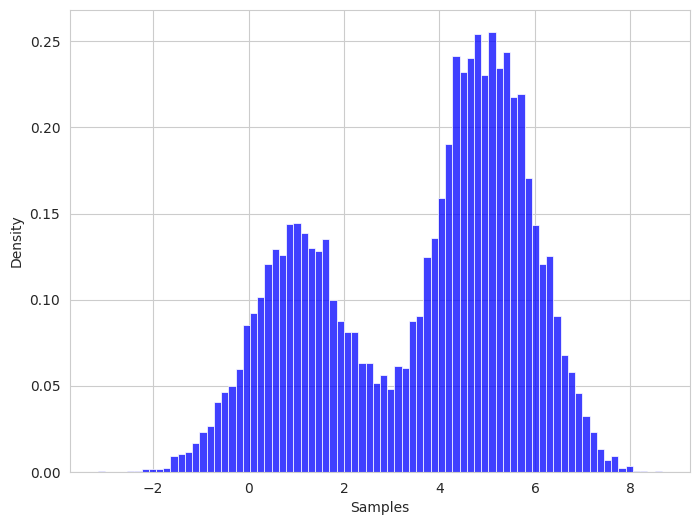

In [4]:
# Define parameters
num_samples = 10000
omega = [0.36, 0.64]
mu = [1, 5]
sigma = [1, 1]

# Generate samples from the Gaussian mixture model
samples = sample_mixture(num_samples, omega, mu, sigma)

sns.set_style("whitegrid")

# Plot histogram
plt.figure(figsize=(8, 6))
sns.histplot(samples, bins=int((max(samples) - min(samples)) / 0.15), kde=False, stat="density", color="blue")

# Set labels
plt.xlabel("Samples")
plt.ylabel("Density")

# Show plot
plt.show()

### 5. Seja
### $$h(x) = [\cos(50x) + \sin(20x)]^2$$
### Vamos considerar estimar $\int_0^1 h(x) dx$ pelo método de Monte Carlo.

### - Primeiro, encontre o valor correto com precisão de $10^{-4}$.
### - É possivel implementar o rejection sampling com uma proposta uniforme?
### - Encontre uma forma de identificar o quão bom está a aproximação.
### - Implemente um importance sampling com uma proposta esperta.

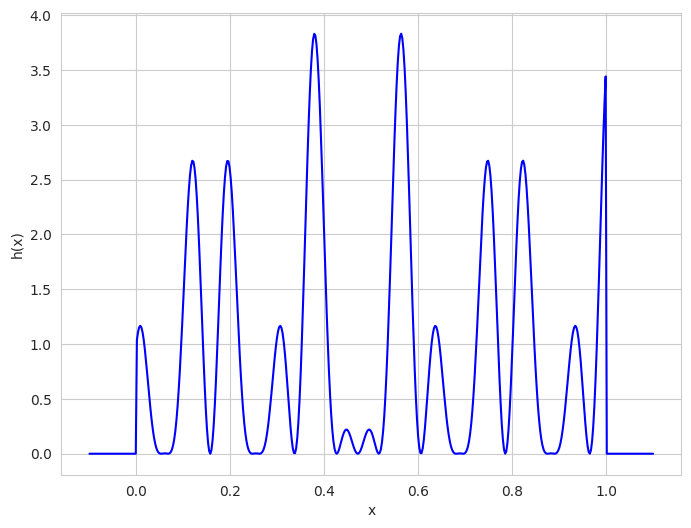

In [5]:
def h(x):
    z = np.where((x > 0) & (x < 1), np.cos(50 * x) + np.sin(20 * x), 0)
    return z**2

# Plot
xs = np.linspace(-0.1, 1.1, 500)
ys = h(xs)

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
plt.plot(xs, ys, color="blue")
plt.xlabel("x")
plt.ylabel("h(x)")

plt.show()

h pode ser integrada analiticamente. Expandindo

$$
h(x) = \cos(50x)^2 + 2 \cos(50x)\sin(20x) + \sin(20x)^2,
$$

a integral em $[0, 1]$ é

$$
H(x) = \frac{x}{2} + \frac{\sin(100x)}{200} + 2 \left[ \frac{\cos(30x)}{60} - \frac{\cos(70x)}{140} \right] + \frac{x}{2} - \frac{\sin(40x)}{80}
$$

em forma de código temos:

In [6]:
def H(x):
    return x/2 + np.sin(100 * x)/200 + 2 * (np.cos(30 * x)/60 - np.cos(70 * x)/140) + x/2 - np.sin(40 * x)/80

print(f"True Value: {H(1)-H(0)}")

True Value: 0.9652009360501459


Primeiro, o rejection sampling com proposta uniforme equivale aqui a um Monte Carlo bruto, já que a integral é em relação à medida uniforme em $[0,1]$

In [7]:
num_repeats = 1000
num_points = 1000
true_value = H(1) - H(0)

# Store Monte Carlo errors
mc_errors = np.empty(num_repeats)

# Perform Monte Carlo simulations
for i in range(num_repeats):
    u = np.random.uniform(size=num_points)
    weights = h(u)
    mc_errors[i] = abs(np.mean(weights) - true_value) / true_value

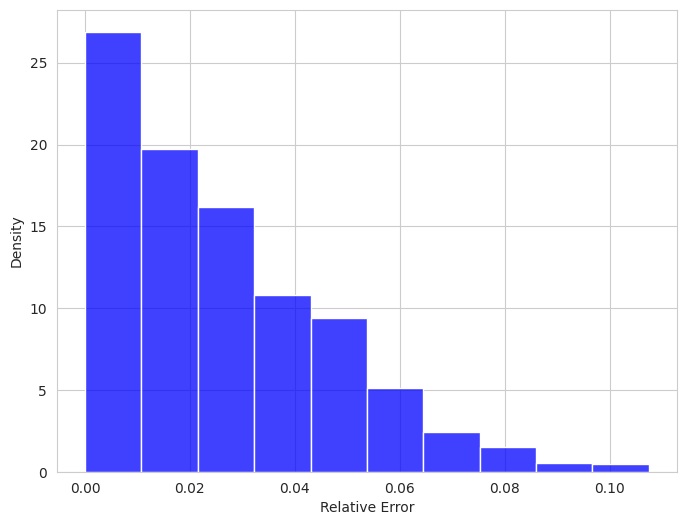

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(mc_errors, bins=int((max(mc_errors) - min(mc_errors)) / 0.01), kde=False, stat="density", color="blue")

plt.xlabel("Relative Error")
plt.ylabel("Density")

plt.show()

Para o nosso plot de h podemos usar que é multimodal. Experamos que seja possivel reduzir a variacia do estimador de Monte Carlo usando importance sampling (IS) com uma proposta de mixtura de Gaussianas. Inicialmente propomos alguns valores.

In [9]:
num_components = 13

omega = np.array([1, 2, 2, 1, 4, 0.2, 0.2, 4, 1, 2, 2, 1, 2])
omega /= np.sum(omega)  # Normalize to sum to 1

# Define means (mu) and standard deviations (sigma)
mu = np.array([0.01, 0.12, 0.195, 0.305, 0.38, 0.45, 0.495, 0.565, 0.635, 0.745, 
               0.825, 0.935, 1])
sigma = np.array([0.02, 0.02, 0.02, 0.02, 0.02, 0.01, 0.01, 0.02, 0.02, 0.02, 
                  0.02, 0.02, 0.02])

# Define the mixture as a list of normal distributions
mixture = [(omega[i], norm(loc=mu[i], scale=sigma[i])) for i in range(num_components)]

In [10]:
xs = np.linspace(0, 1, 500)

# Compute absolute h(x) and normalize
abs_hs = np.abs(h(xs))
normalized_hs = abs_hs / np.sum(abs_hs) * (500 / 1.4)

# Compute mixture density
def dnor_mix(x, mixture):
    return np.sum([w * norm.pdf(x, loc=m, scale=s) for w, (m, s) in zip(omega, zip(mu, sigma))], axis=0)

qs = dnor_mix(xs, list(zip(mu, sigma)))

# Create DataFrame
df = pd.DataFrame({"xs": xs, "hs": abs_hs, "ahs": normalized_hs, "qs": qs})

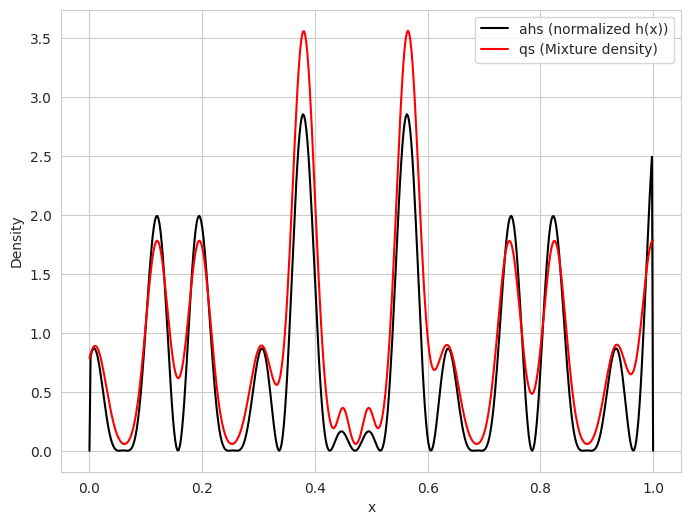

In [11]:
# Plot
plt.figure(figsize=(8, 6))
plt.plot(df["xs"], df["ahs"], color="black", label="ahs (normalized h(x))")
plt.plot(df["xs"], df["qs"], color="red", label="qs (Mixture density)")

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

plt.show()

In [12]:
def rnor_mix(size, mixture):
    # Sample component indices
    component_indices = np.random.choice(len(omega), size=size, p=omega)
    # Sample from the selected normal distributions
    return np.array([np.random.normal(mu[i], sigma[i]) for i in component_indices])

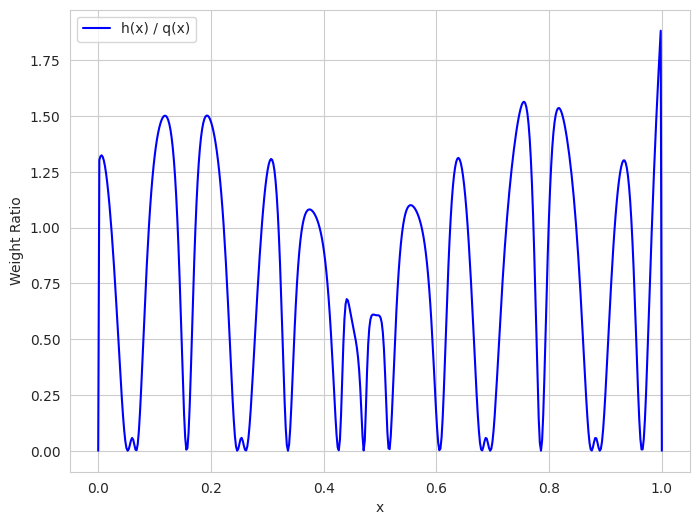

In [13]:
num_repeats = 1000
num_points = 1000
is_errors = np.empty(num_repeats)

for i in range(num_repeats):
    x_samples = rnor_mix(num_points, list(zip(mu, sigma)))
    weights = h(x_samples) / dnor_mix(x_samples, list(zip(mu, sigma)))
    is_errors[i] = np.abs(np.mean(weights) - true_value) / true_value

xs = np.linspace(0, 1, 500)
hs_over_qs = h(xs) / dnor_mix(xs, list(zip(mu, sigma)))

plt.figure(figsize=(8, 6))
plt.plot(xs, hs_over_qs, color="blue", label="h(x) / q(x)")
plt.xlabel("x")
plt.ylabel("Weight Ratio")
plt.legend()
plt.show()

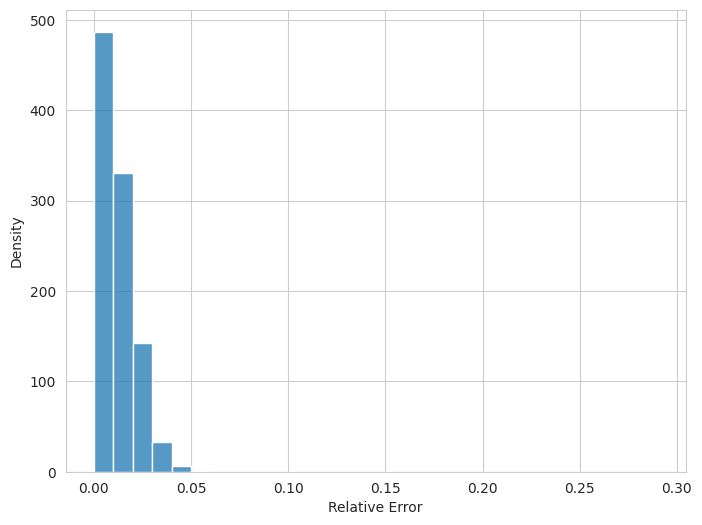

In [14]:
num_repeats = 1000
num_points = 1000
is_errors = np.empty(num_repeats)

for i in range(num_repeats):
    x_samples = rnor_mix(num_points, list(zip(mu, sigma)))
    weights = h(x_samples) / dnor_mix(x_samples, list(zip(mu, sigma)))
    is_errors[i] = np.abs(np.mean(weights) - true_value) / true_value

# Plot Importance Sampling Errors
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.histplot(is_errors, bins=np.arange(0, 0.3, 0.01), kde=False)
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.show()

/tmp/ipykernel_12865/3682362630.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mc_errors, is_errors], labels=["Rejection Sampling", "Importance Sampling"])


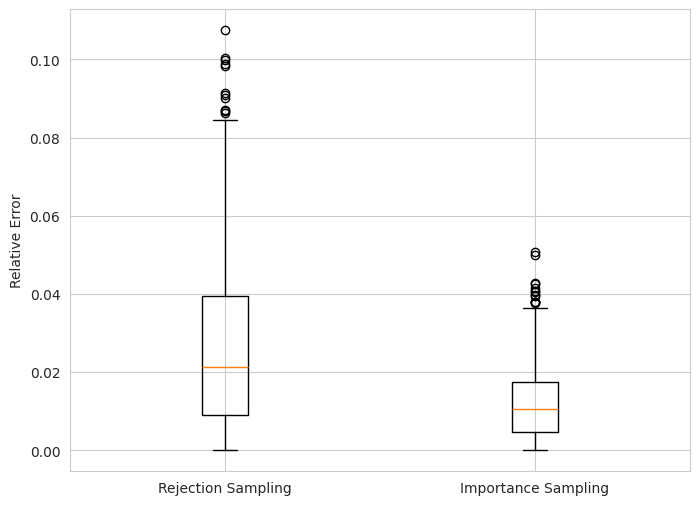

In [15]:
plt.figure(figsize=(8, 6))
plt.boxplot([mc_errors, is_errors], labels=["Rejection Sampling", "Importance Sampling"])
plt.ylabel("Relative Error")
plt.show()

Estimated integral: 0.9589851384900454


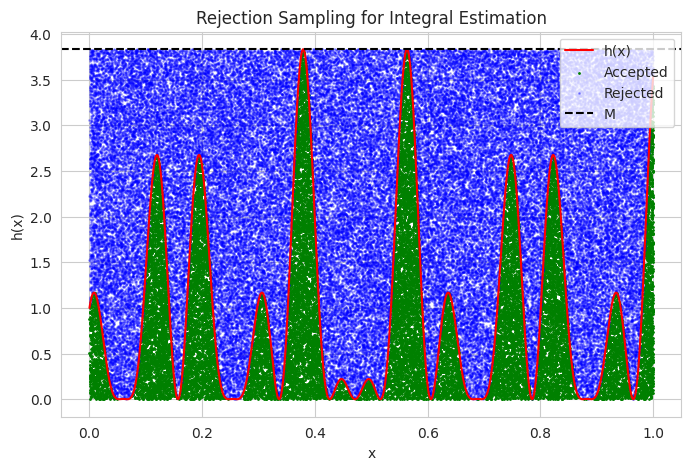

In [16]:
def h(x):
    return (np.cos(50*x) + np.sin(20*x))**2

# Define the bounding constant M
x_vals = np.linspace(0, 1, 1000)
M = max(h(x_vals))  # Upper bound on h(x)

# Number of samples
N = 100000

# Rejection sampling
X_samples = np.random.uniform(0, 1, N)
U_samples = np.random.uniform(0, 1, N) * M

accepted = U_samples <= h(X_samples)

# Estimate the integral
integral_estimate = M * np.mean(accepted)

print(f"Estimated integral: {integral_estimate}")

# Plot h(x) and accepted/rejected points
plt.figure(figsize=(8,5))
plt.plot(x_vals, h(x_vals), 'r-', label='h(x)')
plt.scatter(X_samples[accepted], U_samples[accepted], s=1, color='g', label='Accepted')
plt.scatter(X_samples[~accepted], U_samples[~accepted], s=1, color='b', label='Rejected', alpha=0.3)
plt.axhline(M, color='k', linestyle='--', label='M')
plt.legend()
plt.xlabel('x')
plt.ylabel('h(x)')
plt.title('Rejection Sampling for Integral Estimation')
plt.show()

Estimated integral (Rejection Sampling): 0.962281
Relative error: 3.025331e-03
Estimated integral (Importance Sampling): 0.965303
Relative error: 1.058088e-04


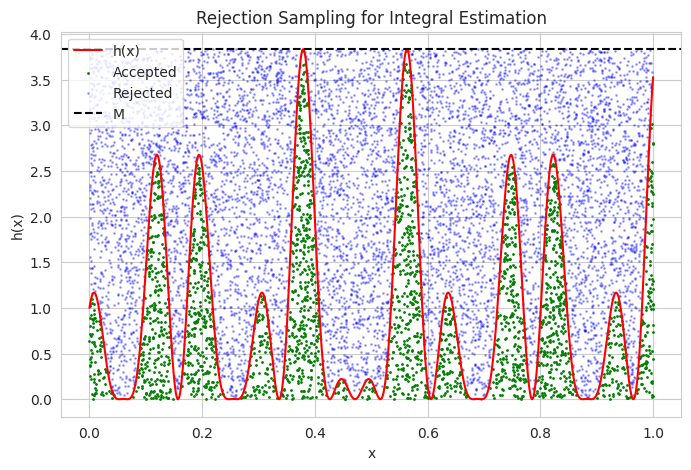

In [17]:
# Define the bounding constant M
x_vals = np.linspace(0, 1, 1000)
M = max(h(x_vals))  # Upper bound on h(x)

# Number of samples
N = 10000

# Rejection sampling
X_samples = np.random.uniform(0, 1, N)
U_samples = np.random.uniform(0, 1, N) * M

accepted = U_samples <= h(X_samples)

# Estimate the integral
integral_estimate = M * np.mean(accepted)
error = abs(integral_estimate - true_value) / true_value

print(f"Estimated integral (Rejection Sampling): {integral_estimate:.6f}")
print(f"Relative error: {error:.6e}")

# Importance Sampling
# Proposal function q(x) ~ h(x) + c
c = 0.5  # Small constant to ensure positivity
q_x = h(x_vals) + c
q_x /= np.trapezoid(q_x, x_vals)  # Normalize q(x) to integrate to 1

# Sample from q(x) using inverse transform sampling
cdf_q = np.cumsum(q_x) / np.sum(q_x)
sampled_indices = np.searchsorted(cdf_q, np.random.rand(N))
X_imp_samples = x_vals[sampled_indices]

# Importance weights
weights = h(X_imp_samples) / q_x[sampled_indices]
integral_imp_estimate = np.mean(weights)
imp_error = abs(integral_imp_estimate - true_value) / true_value

print(f"Estimated integral (Importance Sampling): {integral_imp_estimate:.6f}")
print(f"Relative error: {imp_error:.6e}")

# Plot h(x) and accepted/rejected points
plt.figure(figsize=(8,5))
plt.plot(x_vals, h(x_vals), 'r-', label='h(x)')
plt.scatter(X_samples[accepted], U_samples[accepted], s=1, color='g', label='Accepted')
plt.scatter(X_samples[~accepted], U_samples[~accepted], s=1, color='b', label='Rejected', alpha=0.3)
plt.axhline(M, color='k', linestyle='--', label='M')
plt.legend()
plt.xlabel('x')
plt.ylabel('h(x)')
plt.title('Rejection Sampling for Integral Estimation')
plt.show()